## **Cloning From Repository**

In [1]:
!git clone --branch main https://github.com/paulinaeb/IDaSec-project.git

Cloning into 'IDaSec-project'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 129 (delta 41), reused 85 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 12.19 MiB | 14.29 MiB/s, done.
Resolving deltas: 100% (41/41), done.


## **Necessary** **Imports**

In [2]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
from torch.optim import AdamW
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import DistilBertTokenizer
from sklearn.metrics import accuracy_score
from transformers import DistilBertForSequenceClassification


# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


# **Dataset Loading and Combining**

In [3]:
# Load datasets
enron1_train = pd.read_csv('./IDaSec-project/dataset/enron1/enron1_train.csv')
enron1_val = pd.read_csv('./IDaSec-project/dataset/enron1/enron1_val.csv')
enron1_test = pd.read_csv('./IDaSec-project/dataset/enron1/enron1_test.csv')

enron2_train = pd.read_csv('./IDaSec-project/dataset/enron2/enron2_train.csv')
enron2_val = pd.read_csv('./IDaSec-project/dataset/enron2/enron2_val.csv')
enron2_test = pd.read_csv('./IDaSec-project/dataset/enron2/enron2_test.csv')

sms_train = pd.read_csv('./IDaSec-project/dataset/sms/train.csv')
sms_val = pd.read_csv('./IDaSec-project/dataset/sms/val.csv')
sms_test = pd.read_csv('./IDaSec-project/dataset/sms/test.csv')

# Combine datasets
df_train = pd.concat([enron1_train, enron2_train, sms_train], ignore_index=True)
df_val = pd.concat([enron1_val, enron2_val, sms_val], ignore_index=True)
df_test = pd.concat([enron1_test, enron2_test, sms_test], ignore_index=True)



# **Mapping and Initializing Tokenizer**

In [4]:
# Map 'ham' to 0 and 'spam' to 1
df_train['target'] = df_train['target'].map({'ham': 0, 'spam': 1})
df_val['target'] = df_val['target'].map({'ham': 0, 'spam': 1})
df_test['target'] = df_test['target'].map({'ham': 0, 'spam': 1})

# Initialize tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

## **Tokenizing 'email' column** **and Converting Labels**

In [5]:
# Tokenize the 'email' column
train_inputs = tokenizer(df_train['email'].tolist(), padding=True, truncation=True, max_length=512, return_tensors='pt')
val_inputs = tokenizer(df_val['email'].tolist(), padding=True, truncation=True, max_length=512, return_tensors='pt')
test_inputs = tokenizer(df_test['email'].tolist(), padding=True, truncation=True, max_length=512, return_tensors='pt')

# Move inputs to the selected device
train_inputs = {key: value.to(device) for key, value in train_inputs.items()}
val_inputs = {key: value.to(device) for key, value in val_inputs.items()}
test_inputs = {key: value.to(device) for key, value in test_inputs.items()}

# Convert labels to tensor and move to device
train_labels = torch.tensor(df_train['target'].values).to(device)
val_labels = torch.tensor(df_val['target'].values).to(device)
test_labels = torch.tensor(df_test['target'].values).to(device)


# **Creating DataLoaders**

In [6]:


# Create datasets
train_dataset = TensorDataset(train_inputs['input_ids'], train_inputs['attention_mask'], train_labels)
val_dataset = TensorDataset(val_inputs['input_ids'], val_inputs['attention_mask'], val_labels)
test_dataset = TensorDataset(test_inputs['input_ids'], test_inputs['attention_mask'], test_labels)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


# **Loading Existing DistilBert Model**

In [7]:
from transformers import DistilBertForSequenceClassification

# Load pre-trained model
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Move model to the selected device
model = model.to(device)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# **Initializing Optimizer and Loss Function**

In [8]:


# Initialize optimizer
optimizer = AdamW(model.parameters(), lr=3e-5)

# Initialize loss function
loss_fn = nn.CrossEntropyLoss()


# **Training with Losses and Accuracies**

In [9]:


# Initialize lists to store losses and accuracies
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
for epoch in range(3):  # Adjust number of epochs as needed
    model.train()
    train_loss = 0.0
    train_preds, train_labels = [], []
    for i, batch in enumerate(train_loader, 1):
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        # Print every 10 steps
        if i % 10 == 0:
            train_acc = accuracy_score(train_labels, train_preds)
            print(f"Epoch {epoch+1}, Step {i}, Train Loss: {loss.item():.4f}, Train Acc: {train_acc*100:.2f}%")

    # Calculate average training loss and accuracy
    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = accuracy_score(train_labels, train_preds)
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)

    # Validation loop
    model.eval()
    val_loss = 0.0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for i, batch in enumerate(val_loader, 1):
            input_ids, attention_mask, labels = [b.to(device) for b in batch]
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            val_loss += loss.item()
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

            # Print every 10 steps
            if i % 10 == 0:
                val_acc = accuracy_score(val_labels, val_preds)
                print(f"Epoch {epoch+1}, Step {i}, Val Loss: {loss.item():.4f}, Val Acc: {val_acc*100:.2f}%")

    # Calculate average validation loss and accuracy
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = accuracy_score(val_labels, val_preds)
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)

    # Print losses and accuracies for the epoch
    print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc*100:.2f}%")




Epoch 1, Step 10, Train Loss: 0.4159, Train Acc: 77.50%
Epoch 1, Step 20, Train Loss: 0.3802, Train Acc: 79.14%
Epoch 1, Step 30, Train Loss: 0.1984, Train Acc: 83.85%
Epoch 1, Step 40, Train Loss: 0.1330, Train Acc: 86.33%
Epoch 1, Step 50, Train Loss: 0.0311, Train Acc: 88.31%
Epoch 1, Step 60, Train Loss: 0.0596, Train Acc: 89.71%
Epoch 1, Step 70, Train Loss: 0.1705, Train Acc: 90.78%
Epoch 1, Step 80, Train Loss: 0.1217, Train Acc: 91.68%
Epoch 1, Step 90, Train Loss: 0.1806, Train Acc: 92.26%
Epoch 1, Step 100, Train Loss: 0.0519, Train Acc: 92.72%
Epoch 1, Step 110, Train Loss: 0.1169, Train Acc: 93.28%
Epoch 1, Step 120, Train Loss: 0.0139, Train Acc: 93.66%
Epoch 1, Step 130, Train Loss: 0.0113, Train Acc: 94.04%
Epoch 1, Step 140, Train Loss: 0.0420, Train Acc: 94.31%
Epoch 1, Step 150, Train Loss: 0.0098, Train Acc: 94.62%
Epoch 1, Step 160, Train Loss: 0.1305, Train Acc: 94.82%
Epoch 1, Step 10, Val Loss: 0.0250, Val Acc: 98.28%
Epoch 1, Step 20, Val Loss: 0.0647, Val Acc: 

# **Plotting Losses and Accuracies**

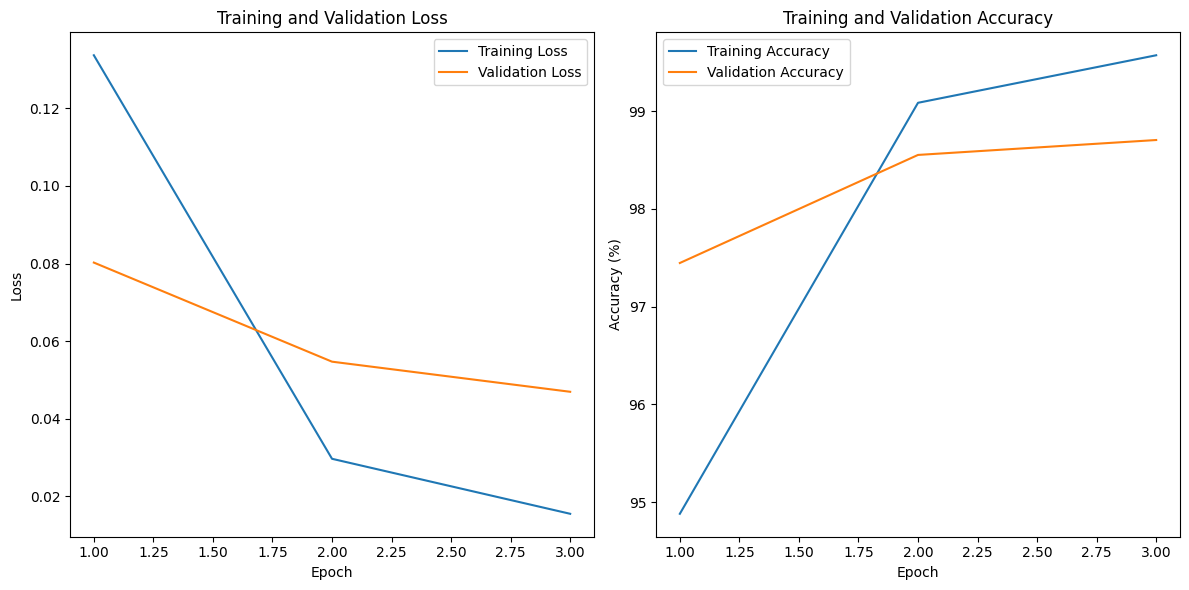

In [10]:
# Plotting the losses
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, 4), train_losses, label='Training Loss')
plt.plot(range(1, 4), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Plotting the accuracies
plt.subplot(1, 2, 2)
plt.plot(range(1, 4), [acc * 100 for acc in train_accuracies], label='Training Accuracy')
plt.plot(range(1, 4), [acc * 100 for acc in val_accuracies], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()